### 📥 Import Required Libraries


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 🖼️ Load the Image

The input image is loaded using OpenCV.

Since OpenCV reads images in **BGR** format by default, it is converted to the **RGB** color space for correct visualization with Matplotlib.

A grayscale version of the image is also created for intensity-based contrast enhancement.

In [ ]:
img = cv2.cvtColor(cv2.imread('lowcontrast2.jpg'),cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

###  Display the Original and Grayscale Images

The original RGB image and its grayscale version are displayed side by side.

The grayscale image contains only intensity information, making it suitable for histogram-based contrast enhancement.

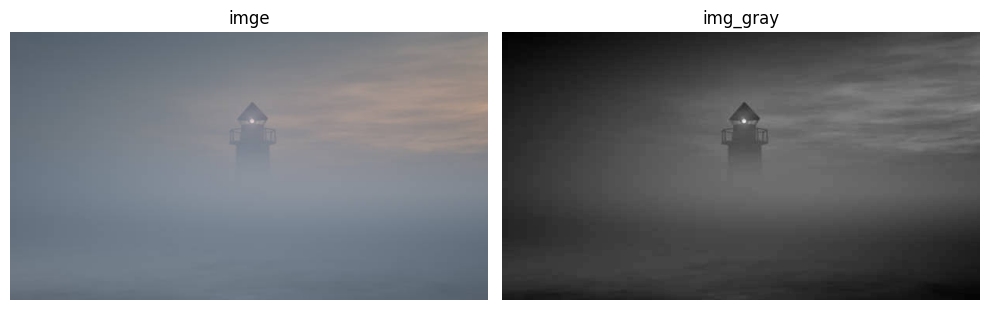

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("imge")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title("img_gray")
plt.axis('off')

plt.tight_layout()
plt.show()

# 📊 Visualize the Histogram

The histogram of the grayscale image is plotted to analyze the intensity distribution.

```python
img_gray.reshape(-1)
```

converts the 2D image into a one-dimensional array so that every pixel intensity can be counted.

A narrow histogram indicates that the image occupies only a small portion of the available intensity range (0–255), resulting in **low contrast**.

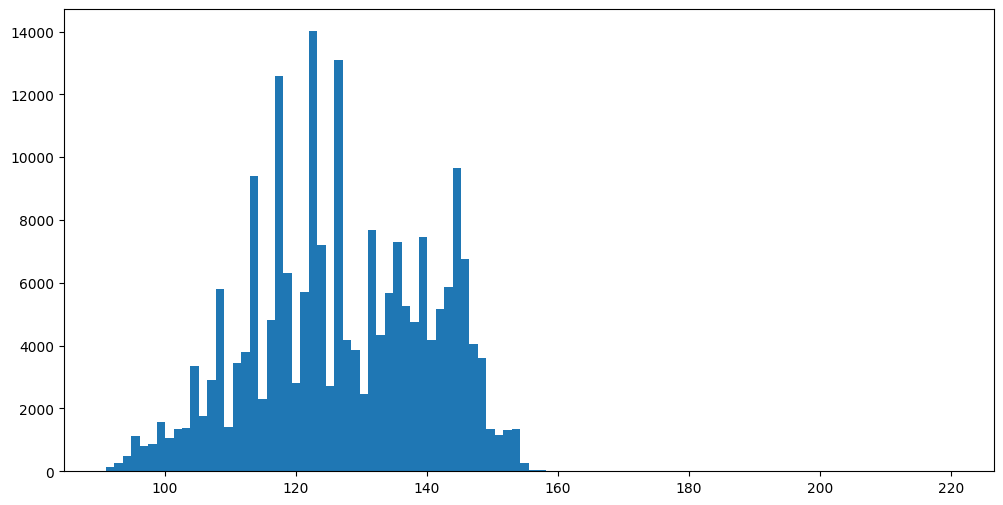

In [15]:
plt.figure(figsize=(12,6))
plt.hist(img_gray.reshape(-1),bins=100)
plt.show()

In [16]:
# histogram Stretching

# 📈 Histogram Stretching (Grayscale Image)

Histogram Stretching is a linear contrast enhancement technique.

The goal is to expand the intensity values so that the minimum intensity becomes **0** and the maximum intensity becomes **255**.

The transformation is defined as:

$$I'=\frac{I-I_{min}}{I_{max}-I_{min}}\times2550$$

where:

- **I** is the original pixel intensity.
- **Imin** is the minimum intensity in the image.
- **Imax** is the maximum intensity in the image.
- **I′** is the transformed intensity.

This linear mapping increases the dynamic range of the image and improves its contrast.

# 🔍 Convert the Image to uint8

The stretching operation produces floating-point values (`float`).

Since standard images are represented as **8-bit unsigned integers (`uint8`)**, the result is converted before visualization.

In [17]:
i_min = img_gray.min()
i_max = img_gray.max()
print("min img_gray:" , i_min)
print("max img_gray:" , i_max)

img_gray_stretchred = ((img_gray-i_min)/(i_max - i_min))*255
print("type of img_gray_stretchred:", img_gray_stretchred.dtype )

# we should convert it to unit8
img_gray_stretchred = img_gray_stretchred.astype('uint8')
print("type of img_gray_stretchred:", img_gray_stretchred.dtype )


img_gray_stretchred_min = img_gray_stretchred.min()
img_gray_stretchred_max = img_gray_stretchred.max()
print("min gray_stretchred:" , img_gray_stretchred_min)
print("max gray_stretchred:" , img_gray_stretchred_max)


min img_gray: 91
max img_gray: 220
type of img_gray_stretchred: float64
type of img_gray_stretchred: uint8
min gray_stretchred: 0
max gray_stretchred: 255


### ⚠️ Sensitivity to Outliers

As shown above, the image has a minimum intensity of **91** and a maximum intensity of **220**. However, the histogram reveals that most pixel intensities are concentrated around **150**, with only a few pixels extending toward the maximum value.

This indicates the presence of **outliers**. These extreme intensity values occupy only a very small portion of the image but still determine the stretching range.

Since Histogram Stretching relies solely on the global minimum and maximum intensity values, these outliers prevent the main body of the histogram from being fully expanded. As a result, the majority of pixels are stretched less than desired, leading to a less effective contrast enhancement.

In this example, a few very bright pixels—such as highlights on the tower—are likely responsible for the maximum intensity. Although these pixels represent only a tiny fraction of the image, they significantly influence the stretching process.

# 🖼️ Compare Before and After Stretching

The original grayscale image and the contrast-enhanced image are displayed side by side.

This comparison highlights the improvement in image contrast and the visibility of fine details.

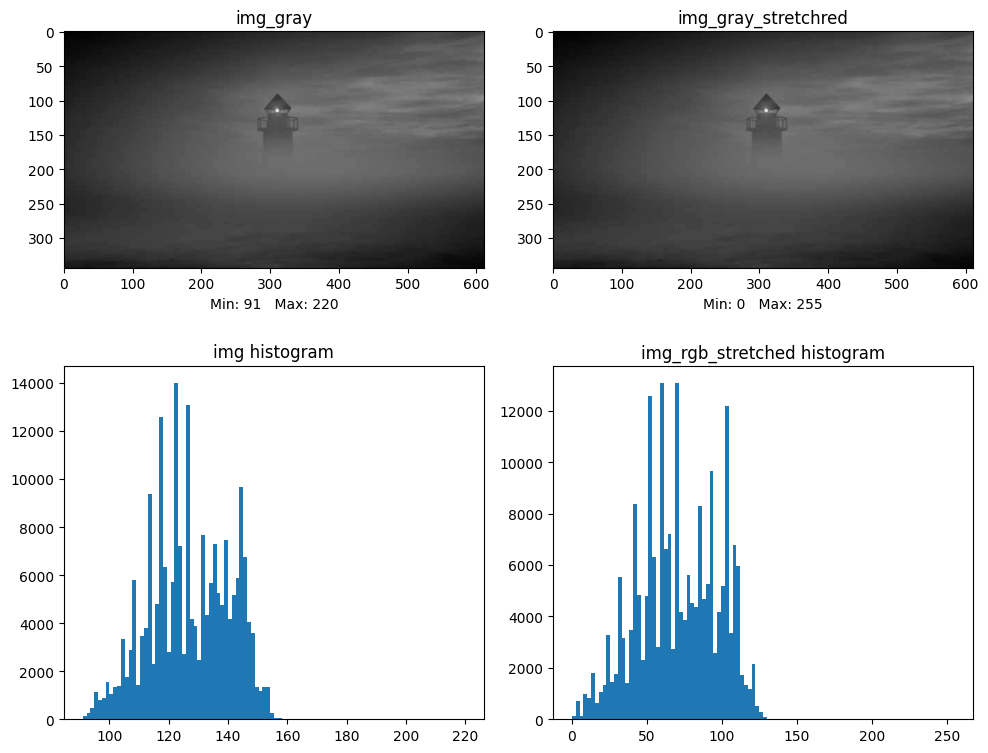

In [27]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("img_gray")
plt.xlabel(f"Min: {img_gray.min()}   Max: {img_gray.max()}")

plt.subplot(2,2,2)
plt.imshow(img_gray_stretchred, cmap='gray')
plt.title("img_gray_stretchred")
plt.xlabel(f"Min: {img_gray_stretchred.min()}   Max: {img_gray_stretchred.max()}")

plt.subplot(2,2,3)
plt.hist(img_gray.reshape(-1), bins=100)
plt.title("img histogram")

plt.subplot(2,2,4)
plt.hist(img_gray_stretchred.reshape(-1), bins=100)
plt.title("img_rgb_stretched histogram")

plt.tight_layout()
plt.show()

###  Histogram Stretching on RGB Channels

For color images, Histogram Stretching is applied independently to each RGB channel.

The procedure consists of the following steps:

1. Split the RGB image into three separate channels.
2. Apply Histogram Stretching to each channel individually.
3. Merge the processed channels back into a single RGB image.

This approach enhances the contrast of each color channel independently.

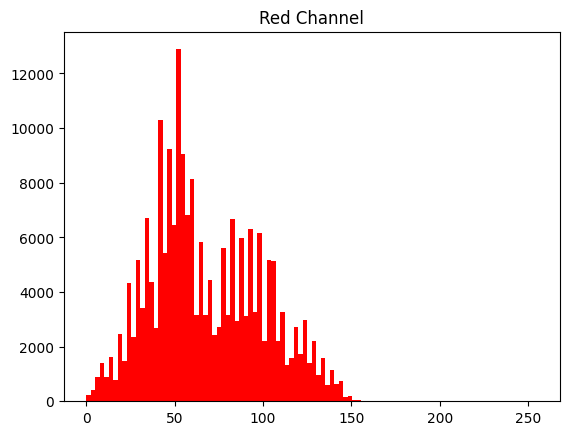

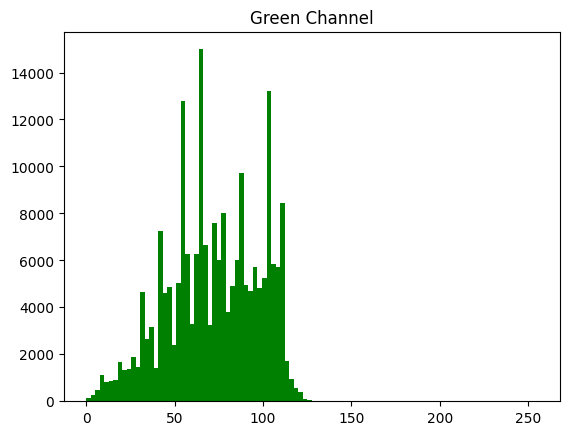

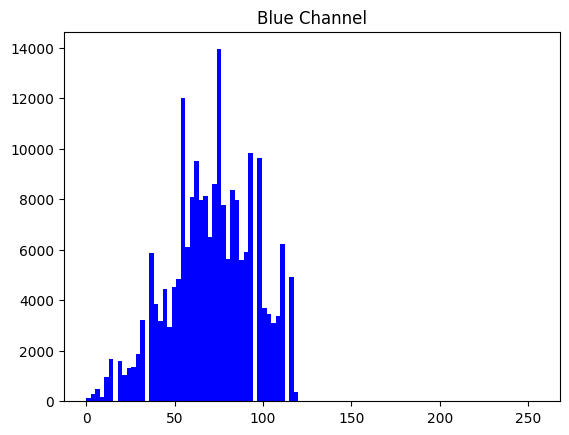

In [19]:
# color image
stretched_channels = []
img_channel = cv2.split(img)

for i, ch in enumerate(img_channel):

    i_min = ch.min()
    i_max = ch.max()

    ch_stretched = ((ch - i_min) / (i_max - i_min) * 255).astype(np.uint8)

    if i == 0:
        plt.hist(ch_stretched.reshape(-1), bins=100, color="red")
        plt.title("Red Channel")

    elif i == 1:
        plt.hist(ch_stretched.reshape(-1), bins=100, color="green")
        plt.title("Green Channel")

    elif i == 2:
        plt.hist(ch_stretched.reshape(-1), bins=100, color="blue")
        plt.title("Blue Channel")

    plt.show()

    stretched_channels.append(ch_stretched)

img_rgb_stretched = cv2.merge(stretched_channels)

# 📊 Histogram of Each Color Channel

After stretching each channel, its histogram is displayed.

These histograms illustrate how the intensity values have been expanded to utilize the full range of **0–255**.

# 🖼️ Compare the Original and Enhanced Color Images

Finally, the original RGB image is compared with the stretched RGB image.

The enhanced image generally exhibits:

- Higher contrast
- Better separation between objects
- Improved visibility of scene details

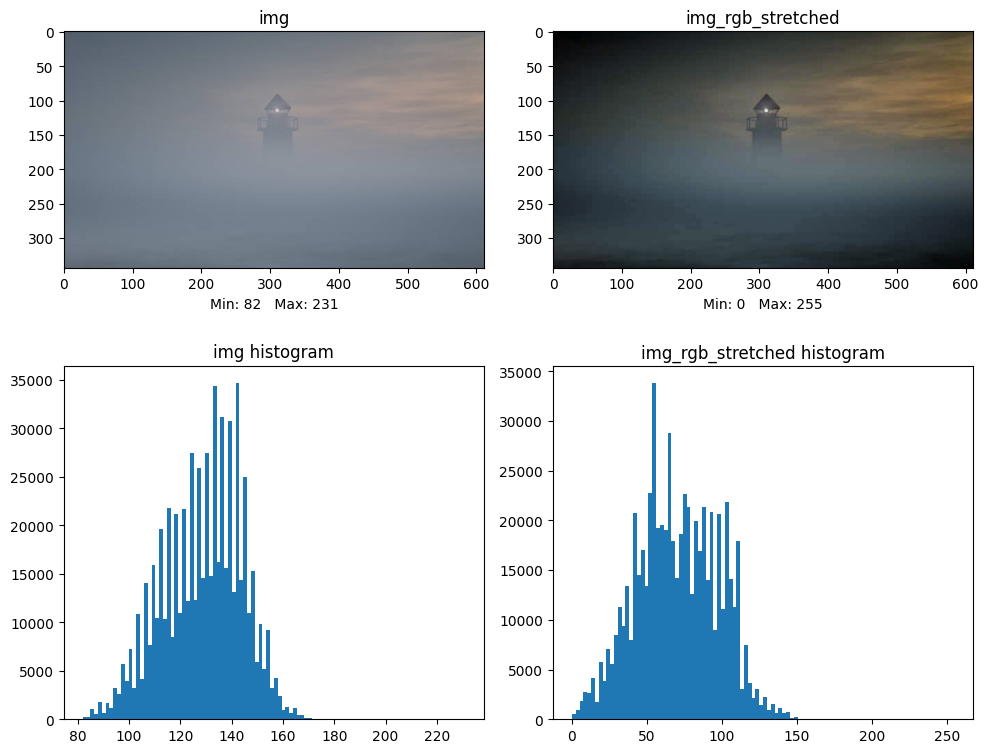

In [26]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title("img")
plt.xlabel(f"Min: {img.min()}   Max: {img.max()}")

plt.subplot(2,2,2)
plt.imshow(img_rgb_stretched, cmap='gray')
plt.title("img_rgb_stretched")
plt.xlabel(f"Min: {img_rgb_stretched.min()}   Max: {img_rgb_stretched.max()}")

plt.subplot(2,2,3)
plt.hist(img.reshape(-1), bins=100)
plt.title("img histogram")

plt.subplot(2,2,4)
plt.hist(img_rgb_stretched.reshape(-1), bins=100)
plt.title("img_rgb_stretched histogram")

plt.tight_layout()
plt.show()

In [ ]:
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("img_gray")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gray_stretchred, cmap='gray')
plt.title("img_gray_stretchred")
plt.axis('off')

# histogram equalization

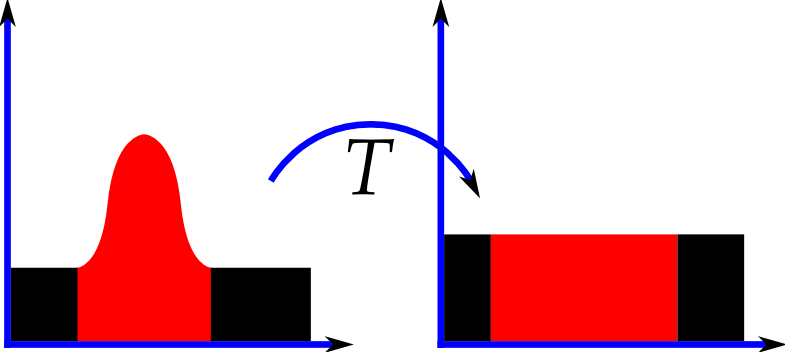


Histograms of an image before and after equalization.

on img gray with compare 


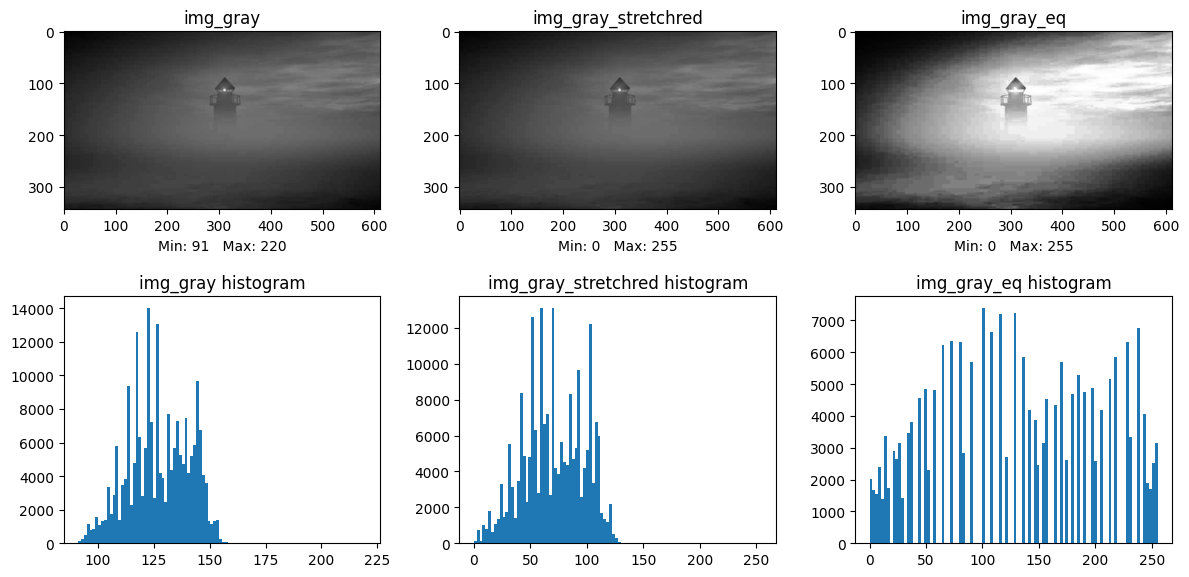

In [34]:

img_gray_eq = cv2.equalizeHist(img_gray)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("img_gray")
plt.xlabel(f"Min: {img_gray.min()}   Max: {img_gray.max()}")

plt.subplot(2,3,2)
plt.imshow(img_gray_stretchred, cmap='gray')
plt.title("img_gray_stretchred")
plt.xlabel(f"Min: {img_gray_stretchred.min()}   Max: {img_gray_stretchred.max()}")

plt.subplot(2,3,3)
plt.imshow(img_gray_eq, cmap='gray')
plt.title("img_gray_eq")
plt.xlabel(f"Min: {img_gray_eq.min()}   Max: {img_gray_eq.max()}")


plt.subplot(2,3,4)
plt.hist(img_gray.reshape(-1), bins=100)
plt.title("img_gray histogram")

plt.subplot(2,3,5)
plt.hist(img_gray_stretchred.reshape(-1), bins=100)
plt.title("img_gray_stretchred histogram")

plt.subplot(2,3,6)
plt.hist(img_gray_eq.reshape(-1), bins=100)
plt.title("img_gray_eq histogram")

plt.tight_layout()
plt.show()

## Comparison between Histogram Stretching and Histogram Equalization

In this comparison, we analyze three different states of the image:

1. Original image (`img_gray`)
2. Image after Histogram Stretching (`img_gray_stretched`)
3. Image after Histogram Equalization (`img_gray_eq`)

---

### Histogram Stretching

The goal of **Histogram Stretching** is to map the current intensity range of the image to a wider range (usually 0 to 255).

As observed in the histogram, this method attempts to expand the intensity range. However, the presence of **outliers** can limit its performance.

If a few pixels have extremely high or extremely low intensity values, these values are considered as the minimum and maximum intensity values. As a result, the main range of image information cannot be properly distributed across the entire intensity range.

Therefore, Histogram Stretching may fail to effectively spread the intensity values when outliers exist in the image.

---

### Histogram Equalization

In **Histogram Equalization**, the goal is not only to increase the intensity range, but also to make the intensity distribution closer to a **uniform distribution**.

In this method, if a large number of pixels are concentrated within a limited intensity range, the algorithm attempts to redistribute these values across a wider range of intensities.

Therefore, Histogram Equalization can reduce the effect of concentrated intensity regions and enhance areas with low contrast.

In the image `img_gray_eq`, we can observe that the contrast has significantly increased compared to the original image, and regions that were unclear in the original image have become more visible.

---

### Important Difference Between Stretching and Equalization

The important point is that **Histogram Equalization, unlike Histogram Stretching, does not only change the intensity range but also modifies the intensity distribution of the image.**

In Histogram Stretching, the general relationship between pixel intensities is preserved, and only the range of values is expanded. Therefore, the overall structure of the brightness distribution remains mostly unchanged.

However, in Histogram Equalization, because the goal is to modify the histogram distribution and make it more uniform, some regions may be enhanced excessively. This can introduce sudden changes in brightness and alter the visual appearance of the image.

As a result, the output image may not always look natural because the algorithm changes the original intensity distribution to improve contrast.

---

### Summary

- **Histogram Stretching**
  - Expands the intensity range of the image.
  - Preserves the overall structure of the intensity distribution.
  - Is sensitive to outliers.

- **Histogram Equalization**
  - Modifies the intensity distribution.
  - Can enhance low-contrast and unclear regions.
  - May change the natural appearance of the image due to intensity redistribution.

### color image

In [35]:
# color image
equ_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    ch_equ = cv2.equalizeHist(ch)
    equ_channels.append(ch_equ)

img_rgb_equ = cv2.merge(equ_channels)

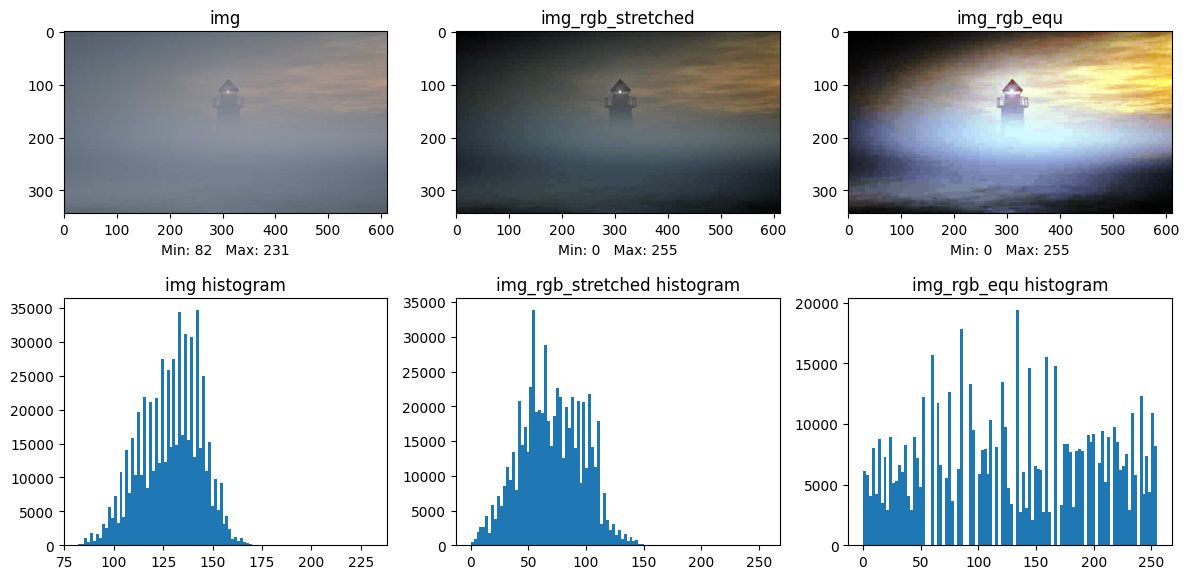

In [37]:

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("img")
plt.xlabel(f"Min: {img.min()}   Max: {img.max()}")

plt.subplot(2,3,2)
plt.imshow(img_rgb_stretched, cmap='gray')
plt.title("img_rgb_stretched")
plt.xlabel(f"Min: {img_rgb_stretched.min()}   Max: {img_rgb_stretched.max()}")

plt.subplot(2,3,3)
plt.imshow(img_rgb_equ, cmap='gray')
plt.title("img_rgb_equ")
plt.xlabel(f"Min: {img_rgb_equ.min()}   Max: {img_rgb_equ.max()}")


plt.subplot(2,3,4)
plt.hist(img.reshape(-1), bins=100)
plt.title("img histogram")

plt.subplot(2,3,5)
plt.hist(img_rgb_stretched.reshape(-1), bins=100)
plt.title("img_rgb_stretched histogram")

plt.subplot(2,3,6)
plt.hist(img_rgb_equ.reshape(-1), bins=100)
plt.title("img_rgb_equ histogram")

plt.tight_layout()
plt.show()

## Effect of Histogram Equalization on Color Images

After applying Histogram Equalization to the RGB image, we can observe that the image is transformed into a higher-contrast representation.

However, an important issue appears: the original color composition of the image may be significantly changed.

Although the output image may look visually enhanced, the colors may not represent the real scene. For example, a background that was originally neutral may become orange, or the sky may appear reddish. These color changes might not exist in the original image and can be artificial color artifacts introduced by the equalization process.

This happens because applying Histogram Equalization directly to RGB channels modifies the intensity distribution of each color channel independently. As a result, the relationship between the RGB channels can change, causing unnatural color shifts.

Compared to Histogram Stretching, Histogram Equalization has a stronger effect on color information and can distort the color composition more significantly. Therefore, although it can improve contrast effectively, the final result may become visually unrealistic and less desirable for color images.

For this reason, Histogram Equalization should be applied carefully to RGB images. In many cases, it is better to convert the image to a color space where intensity is separated from color information (such as HSV/HSB), and apply contrast enhancement only on the intensity channel.


Equalization has a lot of potential to mess up the color scheme.

## Contrast Enhancement in HSV Color Space

In color images, directly applying Histogram Stretching or Histogram Equalization to RGB channels can change the original color composition of the image, because each color channel is processed independently and the relationship between the R, G, and B channels may be altered.

To avoid this issue, the image can be converted into a different color space such as **HSV (Hue, Saturation, Value)**.

In the HSV color space:

- **H (Hue)** represents the main color information of the image.
- **S (Saturation)** represents the intensity or purity of the color.
- **V (Value)** represents the brightness or intensity information of the image.

Since contrast enhancement is mainly related to image intensity, we apply Histogram Stretching and Histogram Equalization only to the **V (Value)** channel while keeping the H and S channels unchanged.

This approach allows us to improve image contrast while preserving the original color information.

In [50]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
h,s,v = cv2.split(img_hsv)

v_min = v.min()
v_max = v.max()
print("min v:" , v_min)
print("max v:" , v_max)

v_stretch = (((v - v_min) / (v_max - v_min)) * 255).astype('uint8')

v_stretch_min = v_stretch.min()
v_stretch_max = v_stretch.max()
print("min v_stretch:" , v_stretch_min)
print("max v_stretch:" , v_stretch_max)


img_hsv_stretched = cv2.merge([h,s,v_stretch])

v_equ = cv2.equalizeHist(v)

img_hsv_equ = cv2.merge([h,s,v_equ])


img_hsv_show = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
img_hsv_stretched_show = cv2.cvtColor(img_hsv_stretched,cv2.COLOR_HSV2RGB)
img_hsv_equ_show = cv2.cvtColor(img_hsv_equ,cv2.COLOR_HSV2RGB)


min v: 105
max v: 231
min v_stretch: 0
max v_stretch: 255


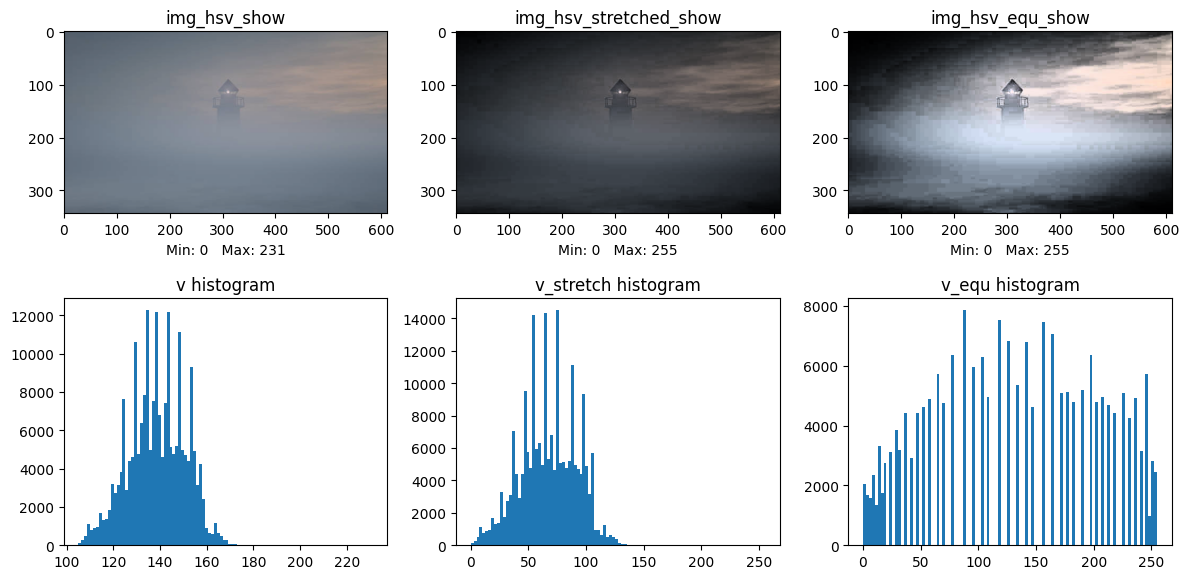

In [51]:

img_gray_eq = cv2.equalizeHist(img_gray)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_hsv_show)
plt.title("img_hsv_show")
plt.xlabel(f"Min: {img_hsv.min()}   Max: {img_hsv.max()}")

plt.subplot(2,3,2)
plt.imshow(img_hsv_stretched_show)
plt.title("img_hsv_stretched_show")
plt.xlabel(f"Min: {v_stretch.min()}   Max: {v_stretch.max()}")

plt.subplot(2,3,3)
plt.imshow(img_hsv_equ_show, cmap='gray')
plt.title("img_hsv_equ_show")
plt.xlabel(f"Min: {v_equ.min()}   Max: {v_equ.max()}")


plt.subplot(2,3,4)
plt.hist(v.reshape(-1), bins=100)
plt.title("v histogram")

plt.subplot(2,3,5)
plt.hist(v_stretch.reshape(-1), bins=100)
plt.title("v_stretch histogram")

plt.subplot(2,3,6)
plt.hist(v_equ.reshape(-1), bins=100)
plt.title("v_equ histogram")

plt.tight_layout()
plt.show()